In [1]:
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

In [2]:
# Define consistent color palette for the entire analysis
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Gender color mapping for easy reference
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE,
    'Combined': COLOR_COMBINED
}

# Exam Performance Analysis


## 1. Data Loading

The cleaned exam data is loaded from the CSV file.

In [3]:
df = load_data("../data/cleaned_data/IN1020_2025konte_cleaned_data.csv")
#extract exam name from file name 
exam_name = Path("../data/cleaned_data/IN1020_2025konte_cleaned_data.csv").stem.split("_cleaned_data")[0]

Data loaded successfully from ../data/cleaned_data/IN1020_2025konte_cleaned_data.csv


In [4]:
df.head()

,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2026-01-22 14:01:25,2026-01-22 15:33:03,0,0,55,2.0,1.1,IN1020 K-H25 bit-representasjon,225,2.0,simpleChoice_1368096164456,-85,68.25
1,2026-01-22 14:01:25,2026-01-22 15:33:03,0,0,55,2.0,1.1,IN1020 K-H25 bit-representasjon,225,2.0,simpleChoice_1368096164453,171,68.25
2,2026-01-22 14:01:25,2026-01-22 15:33:03,0,0,55,3.5,1.2,IN1020 K-H25 Tallsystemer representasjon,97,3.0,simpleChoice_1368096164456,cafebabe,68.25
3,2026-01-22 14:01:25,2026-01-22 15:33:03,0,0,55,3.5,1.2,IN1020 K-H25 Tallsystemer representasjon,97,3.0,simpleChoice_IA17639200973561dd93152-292d-4b6b...,123hh321,68.25
4,2026-01-22 14:01:25,2026-01-22 15:33:03,0,0,55,3.5,1.2,IN1020 K-H25 Tallsystemer representasjon,97,3.0,simpleChoice_1368096164453,0f0cdb0d,68.25



## Overview

In [5]:
print(f"This notebook provides a comprehensive analysis of exam performance for {exam_name}. ")

This notebook provides a comprehensive analysis of exam performance for IN1020_2025konte. 


The analysis examines:

- **Score distributions** across all students
- **Descriptive statistics** (mean, median, standard deviation, quartiles, skewness, kurtosis)
- **Gender distribution** visualization
- **Time usage patterns** and their relationship with exam scores
- **Outlier detection** in both scores and time usage

The analysis focuses on combined data (all students) to understand overall exam performance patterns.

## 2. Data Preparation

Two datasets are created for different aspects of the analysis:

- **`df_total_score`**: Contains unique student records with gender and total score for overall performance analysis
- **`df_time`**: Contains exam timing data with calculated time taken in minutes for time usage analysis

In [7]:
# Prepare student-level dataset with unique records per student
df_total_score = df.groupby('student_id').agg({
    # 'gender': 'first',
    'total_score': 'first'
}).reset_index()

# Prepare a subset for exam time analysis
df_time = df.groupby('student_id').agg({
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'total_score': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

#add column with time taken to complete the exam in minutes
df_time['time_taken'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.dropna(subset=['time_taken'])

In [8]:
print("Combined dataset (male and female students):")
df_total_score.head()

Combined dataset (male and female students):


,student_id,total_score
0,1,88.50
1,2,63.25
2,3,49.76
3,4,80.50
4,5,29.16


In [9]:
print("Dataset with time taken to complete the exam:")
df_time.head()

Dataset with time taken to complete the exam:


,student_id,exam_start_time,exam_end_time,total_score,extra_time_mins,incident_time_mins,time_taken
0,1,2026-01-22 14:00:02,2026-01-22 15:56:19,88.50,0,0,116.28
1,2,2026-01-22 14:00:02,2026-01-22 15:21:46,63.25,0,0,81.73
2,3,2026-01-22 14:00:01,2026-01-22 16:49:25,49.76,0,0,169.40
3,4,2026-01-22 14:00:01,2026-01-22 15:36:30,80.50,30,0,96.48
4,5,2026-01-22 14:00:05,2026-01-22 17:57:29,29.16,0,0,237.40


---

## 3. Descriptive Statistics

This section presents comprehensive statistical measures for the total scores, including:
- Central tendency measures (mean, median, mode)
- Dispersion measures (standard deviation, range, IQR)
- Distribution shape indicators (skewness, kurtosis)

In [10]:
# Enhanced descriptive statistics table
def calculate_descriptive_stats(data, name):
    """Calculate comprehensive descriptive statistics"""
    stats_dict = {
        'Count': len(data),
        'Mean': round(data.mean(), 2),
        'Median': round(data.median(), 2),
        'Mode': round(data.mode()[0], 2),
        'Std Dev': round(data.std(), 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Q1': round(data.quantile(0.25), 2),
        'Q3': round(data.quantile(0.75), 2),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        'Skewness': round(data.skew(), 3),
        'Kurtosis': round(data.kurtosis(), 3)
    }
    return pd.Series(stats_dict, name=name)

# Create comprehensive statistics table
descriptive_stats = pd.DataFrame([
    calculate_descriptive_stats(df_total_score['total_score'], 'Combined'),
]).T

print("=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===")
print(descriptive_stats)


=== DESCRIPTIVE STATISTICS FOR TOTAL SCORES ===
          Combined
Count       68.000
Mean        60.120
Median      60.550
Mode        63.250
Std Dev     13.760
Min         27.700
Max         88.500
Q1          49.640
Q3          69.090
IQR         19.450
Skewness    -0.144
Kurtosis    -0.356


### 3.1 Gender Distribution

The following pie chart shows the proportion of male and female students in the exam.

In [11]:
# Gender distribution pie chart
# plt.figure(figsize=(8, 6))
# # Ensure consistent order: Female first, then Male
# gender_counts = df['gender'].value_counts().reindex(['F', 'M'])
# plt.pie(gender_counts, autopct='%1.1f%%', 
#         colors=[COLOR_FEMALE, COLOR_MALE], 
#         startangle=140,
#         labels=['Female', 'Male'])
# plt.title("Gender Distribution")
# plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
# plt.show()

### 3.2 Score Distribution Histogram

This section visualizes the score distribution with key statistical measures overlaid:
- **Red dashed line**: Mean score
- **Green solid line**: Median score
- **Purple shaded area**: ±1 standard deviation from the mean (meaning that approximately 68% of the data points fall within this range)
- **Skewness value**: Indicates whether the distribution is symmetric, left-skewed, or right-skewed

In [12]:
def plot_enhanced_distributions(df, ax, title, ylabel, color='lightblue'):
    """Create enhanced distribution plots with statistical annotations"""
    mean_val = df['total_score'].mean()
    median_val = df['total_score'].median()
    std_val = df['total_score'].std()
    skew_val = df['total_score'].skew()
    
    total_students = len(df)
    
    # Create histogram with percentage weights
    n, bins, patches = ax.hist(df['total_score'], bins=20, color=color, edgecolor='gray', alpha=0.7, 
             weights=np.ones(len(df))/total_students*100)
    
    # Add statistical lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
    ax.axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')
    
    # Add skewness annotation
    ax.text(0.05, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax.set_xlabel("Total Score")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    # Set y-limit to maximum y-value plus 2
    max_y = max(n)
    ax.set_ylim(0, max_y+2)
    ax.legend()

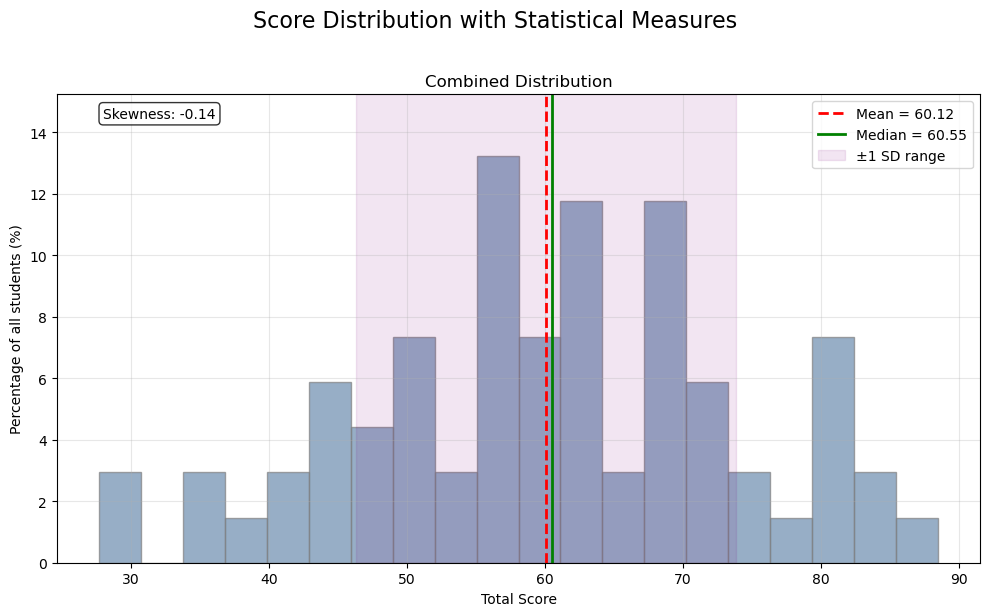

=== DISTRIBUTION SHAPE INTERPRETATION ===
Combined: approximately symmetric (skewness = -0.144)


In [13]:
# Create enhanced distribution plot
fig, ax = plt.subplots(figsize=(10, 6))

plot_enhanced_distributions(df_total_score, ax, "Combined Distribution", 
                          "Percentage of all students (%)", COLOR_COMBINED)

plt.suptitle("Score Distribution with Statistical Measures", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of skewness
print("=== DISTRIBUTION SHAPE INTERPRETATION ===")
skew = df_total_score['total_score'].skew()
if abs(skew) < 0.5:
    shape = "approximately symmetric"
elif skew > 0.5:
    shape = "right-skewed (positive skew)"
else:
    shape = "left-skewed (negative skew)"
print(f"Combined: {shape} (skewness = {skew:.3f})")

---

## 4. Time Usage Analysis

This section examines how long students took to complete the exam and explores the relationship between time taken and exam scores. Key aspects analyzed:
- Time distribution statistics
- Time outliers
- Correlation between time and performance

### 4.1 Time Statistics

In [14]:
# Time analysis descriptive statistics
time_stats = pd.DataFrame([
    calculate_descriptive_stats(df_time['time_taken'], 'Combined'),
]).T

print("=== TIME ANALYSIS DESCRIPTIVE STATISTICS IN MIN===")
print(time_stats)

=== TIME ANALYSIS DESCRIPTIVE STATISTICS IN MIN===
          Combined
Count       68.000
Mean       129.750
Median     124.780
Mode        39.350
Std Dev     53.200
Min         39.350
Max        261.780
Q1          87.780
Q3         166.480
IQR         78.690
Skewness     0.591
Kurtosis    -0.445


### 4.2 Time Distribution Visualizations

The following visualizations provide different perspectives on time usage:
1. **Histogram**: Overall time distribution with statistical measures
2. **Boxplot**: Identifies outliers in time usage
3. **Violin plot**: Shows the density of time distribution
4. **Scatter plot**: Examines the relationship between time taken and exam score

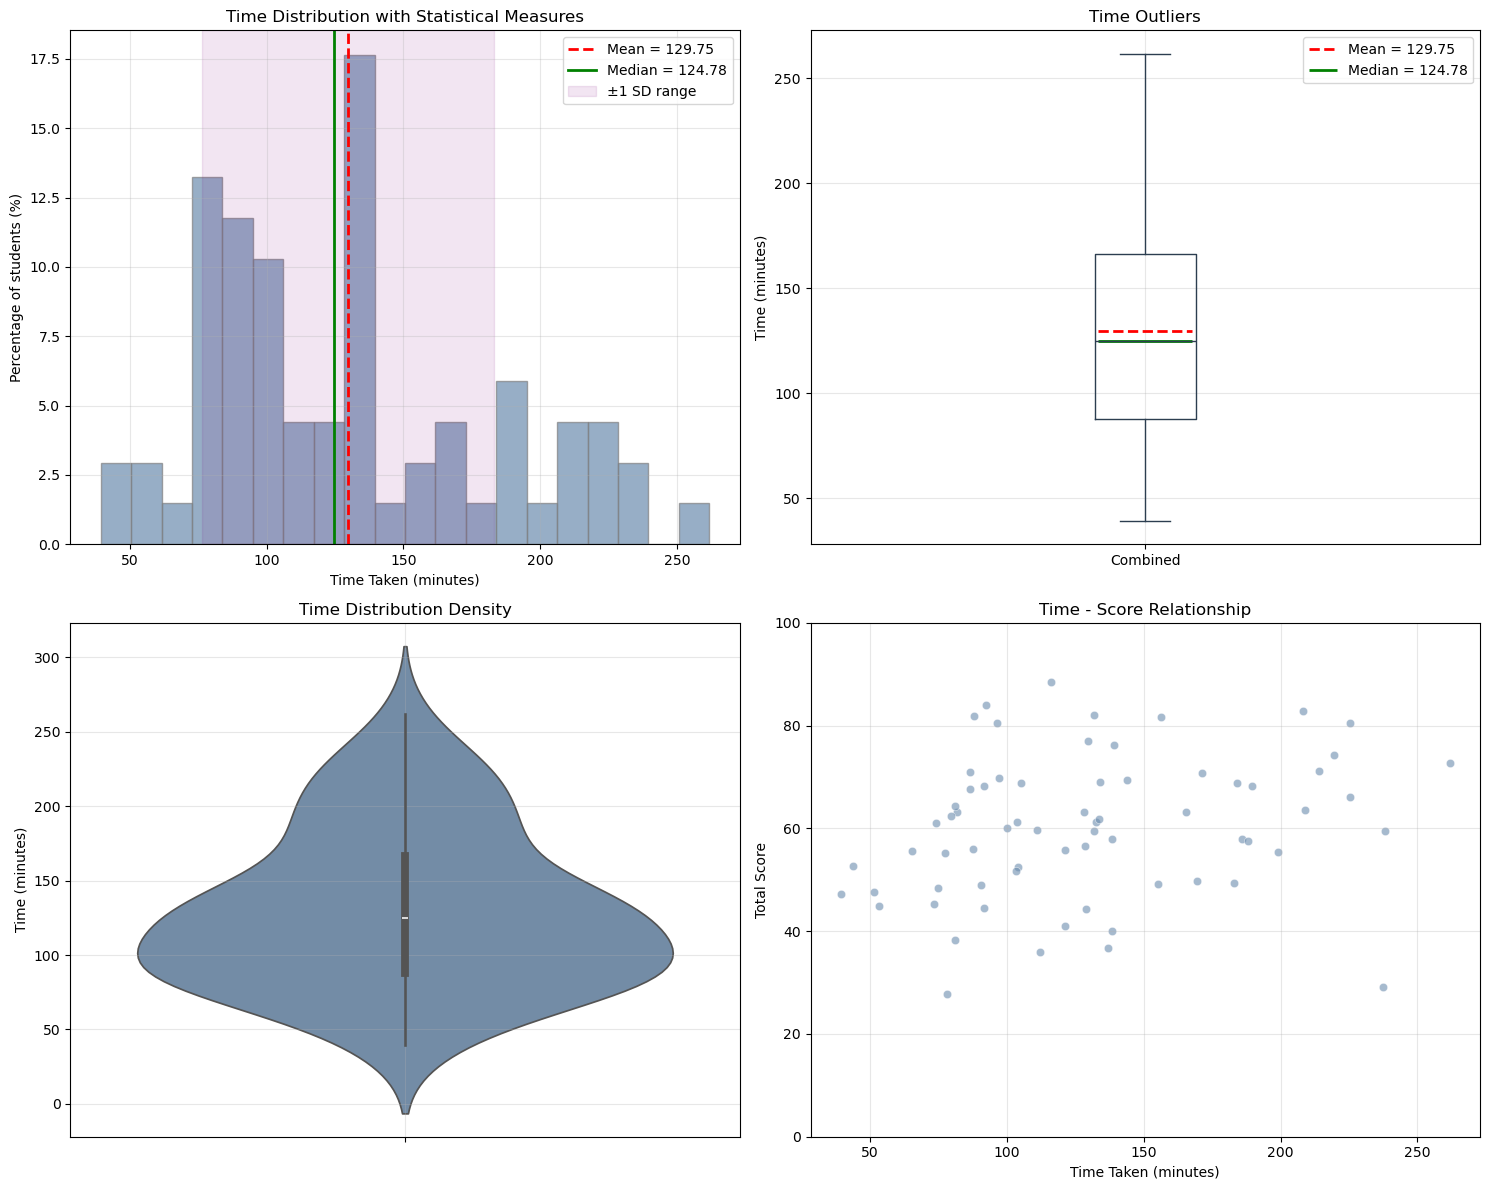

In [15]:
# Enhanced time analysis visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Calculate statistics once for use in all plots
mean_val = df_time['time_taken'].mean()
median_val = df_time['time_taken'].median()
std_val = df_time['time_taken'].std()
total_students = len(df_time)

# Histogram for time distribution
n, bins, patches = axes[0, 0].hist(df_time['time_taken'], bins=20, color=COLOR_COMBINED, 
                                    edgecolor='gray', alpha=0.7,
                                    weights=np.ones(len(df_time))/total_students*100)

# Add statistical lines to histogram
axes[0, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
axes[0, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
axes[0, 0].axvspan(mean_val - std_val, mean_val + std_val, color='purple', alpha=0.1, label='±1 SD range')

axes[0, 0].set_xlabel("Time Taken (minutes)")
axes[0, 0].set_ylabel("Percentage of students (%)")
axes[0, 0].set_title("Time Distribution with Statistical Measures")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Boxplot for time distribution
df_time[['time_taken']].boxplot(ax=axes[0, 1], return_type='dict', color=COLOR_BOXPLOT)
axes[0, 1].set_title("Time Outliers")
axes[0, 1].set_ylabel("Time (minutes)")
axes[0, 1].set_xticklabels(['Combined'])
axes[0, 1].grid(True, alpha=0.3)

# Add mean and median lines inside the box
axes[0, 1].hlines(mean_val, 0.93, 1.07, colors='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
axes[0, 1].hlines(median_val, 0.93, 1.07, colors='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
axes[0, 1].legend(loc='upper right')

# Violin plot for time distribution
sns.violinplot(data=df_time, y='time_taken', ax=axes[1, 0], 
               color=COLOR_COMBINED, inner='box')
axes[1, 0].set_title('Time Distribution Density')
axes[1, 0].set_ylabel('Time (minutes)')
axes[1, 0].grid(True, alpha=0.3)

# Time vs Score relationship - Combined data
sns.scatterplot(data=df_time, x='time_taken', y='total_score', 
               alpha=0.6, ax=axes[1, 1], color=COLOR_COMBINED)
axes[1, 1].set_title("Time - Score Relationship")
axes[1, 1].set_xlabel("Time Taken (minutes)")
axes[1, 1].set_ylabel("Total Score")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# explanation of why there are some students who spent more than 241 minutes on the exam (based on extra time and incident time)
print("=== EXPLANATION FOR EXTENDED EXAM DURATION ===")
counter_extra_time = 0
counter_incident_time = 0
counter_both = 0
counter_extra_time_only = 0
counter_incident_time_only = 0
extended_time_students = df_time[df_time['time_taken'] > 241]
for index, row in extended_time_students.iterrows():
    has_extra_time = not pd.isna(row['extra_time_mins']) and row['extra_time_mins'] > 0
    has_incident_time = not pd.isna(row['incident_time_mins']) and row['incident_time_mins'] > 0
    
    if has_extra_time:
        counter_extra_time += 1
    if has_incident_time:
        counter_incident_time += 1
    
    if has_extra_time and has_incident_time:
        counter_both += 1
    elif has_extra_time:
        counter_extra_time_only += 1
    elif has_incident_time:
        counter_incident_time_only += 1


print(f"Some students spent more than the standard exam duration of 240 minutes due to extra time and incident-related extensions.")
print(f"Students with extra time (total): {counter_extra_time}")
print(f"Students with incident time (total): {counter_incident_time}")
print(f"Students with extra time only: {counter_extra_time_only}")
print(f"Students with incident time only: {counter_incident_time_only}")
print(f"Students with both accommodations: {counter_both}")
print()
if len(extended_time_students) - (counter_extra_time_only + counter_incident_time_only + counter_both) > 0:
    print(f"Reason for extended time among other {len(extended_time_students) - (counter_extra_time_only + counter_incident_time_only + counter_both)} students is unknown.")

=== EXPLANATION FOR EXTENDED EXAM DURATION ===
Some students spent more than the standard exam duration of 240 minutes due to extra time and incident-related extensions.
Students with extra time (total): 1
Students with incident time (total): 0
Students with extra time only: 1
Students with incident time only: 0
Students with both accommodations: 0

